# 동대문구 아파트 실거래가 EDA

## 배경
서울시 아파트 입지 특성을 반영한 주택담보대출 리스크 평가 모델을 만드는 프로젝트의 파일럿 자치구(동대문구) EDA 단계입니다.

**데이터**: `202501-202512 동대문구.csv` (국토교통부 아파트매매 실거래 상세자료, 2025년 1~12월, 4,064건)

**컬럼**: aptNm(단지명), umdNm(법정동), jibun(지번), excluUseAr(전용면적㎡), dealYear/dealMonth/dealDay(계약일),
dealAmount(거래금액, 만원, 콤마 포함 문자열), floor(층), buildYear(건축년도), aptDong(동), buyerGbn(매수자구분),
cdealDay/cdealType(해제사유발생일/해제여부), dealingGbn(중개·직거래), estateAgentSggNm(중개소재지),
landLeaseholdGbn(대지권여부), rgstDate(등기일자), sggCd(법정동코드), slerGbn(매도자구분)

## 진행 원칙
- 각 단계마다 처리 근거(분포 형태, 상관계수 등 실제 수치)를 먼저 확인하고 나서 처리 방향을 정한다. "일반적으로 그렇게 한다"는 이유만으로 로그변환·이상치 제거를 적용하지 않는다.
- 분석 단위(법정동 vs 단지)나 변수 선택 등 판단이 필요한 지점은 근거를 제시하고 결론을 명시한다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats

plt.rcParams['axes.unicode_minus'] = False
for fname in ['AppleGothic', 'Malgun Gothic', 'NanumGothic']:
    if any(fname in f.name for f in fm.fontManager.ttflist):
        plt.rcParams['font.family'] = fname
        break

sns.set_style('whitegrid')

df = pd.read_csv("202501-202512 동대문구.csv")
print(df.shape)
df.head()

(4064, 20)


,aptNm,umdNm,jibun,excluUseAr,dealYear,dealMonth,dealDay,dealAmount,floor,buildYear,aptDong,buyerGbn,cdealDay,cdealType,dealingGbn,estateAgentSggNm,landLeaseholdGbn,rgstDate,sggCd,slerGbn
0,대우,이문동,45,84.891,2025,1,18,"77,000",4,2001,103,개인,NaN,NaN,중개거래,서울 동대문구,N,25.04.15,11230,개인
1,주공1,휘경동,57,84.840,2025,1,22,"79,500",2,2001,112,개인,NaN,NaN,중개거래,"경기 고양시 덕양구, 서울 동대문구",N,25.05.12,11230,개인
2,청계한신휴플러스,답십리동,1002,84.730,2025,1,13,"106,500",1,2010,102,개인,NaN,NaN,중개거래,서울 동대문구,N,25.06.09,11230,개인
3,동서울한양,답십리동,41,59.670,2025,1,4,"51,000",12,1989,2,개인,NaN,NaN,중개거래,서울 동대문구,N,25.03.31,11230,개인
4,두산위브,답십리동,998,84.910,2025,1,11,"112,500",13,2007,106,개인,NaN,NaN,중개거래,서울 동대문구,N,25.05.07,11230,개인


## 1단계 — 데이터 클리닝

목표: (1) `dealAmount` 숫자형 변환 (2) 해제거래(`cdealType=='O'`) 처리 방향 결정 (3) 완전 중복행 처리 (4) 결측치 현황 파악 (5) 거래유형(중개/직거래, 매수·매도자 구분)별 가격 차이 확인.

각 처리는 아래에서 실제 수치를 먼저 확인한 뒤 결정한다.

In [2]:
df['dealAmount_num'] = df['dealAmount'].str.replace(',', '').astype(int)
df[['dealAmount', 'dealAmount_num']].head()

,dealAmount,dealAmount_num
0,"77,000",77000
1,"79,500",79500
2,"106,500",106500
3,"51,000",51000
4,"112,500",112500


### 해제거래(cdealType) 비율 및 가격 비교

먼저 해제거래 비율과, 해제거래가 정상거래와 가격대가 실제로 다른지 확인한다.

In [3]:
df['is_cancelled'] = df['cdealType'] == 'O'
print("해제거래 건수/비율:", df['is_cancelled'].sum(), f"({df['is_cancelled'].mean():.2%})")

df['ppm2_raw'] = df['dealAmount_num'] / df['excluUseAr']
print()
print("정상 vs 해제거래 ㎡당가격 중위값 비교:")
print(df.groupby('is_cancelled')['ppm2_raw'].median())

u = stats.mannwhitneyu(df.loc[df.is_cancelled, 'ppm2_raw'], df.loc[~df.is_cancelled, 'ppm2_raw'])
print(f"\nMann-Whitney U 검정 p-value = {u.pvalue:.3f}")

해제거래 건수/비율: 311 (7.65%)

정상 vs 해제거래 ㎡당가격 중위값 비교:
is_cancelled
False    1216.940074
True     1250.625313
Name: ppm2_raw, dtype: float64

Mann-Whitney U 검정 p-value = 0.144


**판단**: 해제거래(311건, 7.65%)의 ㎡당가격은 정상거래와 통계적으로 유의한 차이가 없다(p=0.144) — 즉 "가격이 이상해서" 해제된 것은 아니다. 다만 해제거래는 **법적으로 계약이 취소되어 최종 성사되지 않은 거래**이므로, 시세를 대표하는 표본으로 보기 어렵다. 따라서:
- 원본 데이터는 보존하고 `is_cancelled` 플래그만 추가
- 3단계 이후 가격 분포·시세 분석에서는 해제거래를 제외한 표본을 기본으로 사용 (개념적 이유이지 이상치라서가 아님)

### 완전 중복행 처리

완전 중복행(모든 컬럼 값 동일)이 얼마나 있고, 어떤 성격인지 확인한다.

In [4]:
dup_all = df.duplicated(keep=False)
print("완전 중복행(자기 자신 포함) 수:", dup_all.sum())

dups = df[dup_all]
print()
print("중복행이 속한 단지별 건수:")
print(dups['aptNm'].value_counts())
print()
print("중복행의 buyerGbn 구성:")
print(dups.groupby('aptNm')['buyerGbn'].unique())

완전 중복행(자기 자신 포함) 수: 105

중복행이 속한 단지별 건수:
aptNm
장안동하트리움         52
LOFT129         33
청계한신휴플러스         4
휘경SK뷰            2
휘경제이스카이아파트       2
이편한세상청계센트럴포레     2
래미안이문2차          2
래미안 허브리츠         2
장안현대홈타운(336)     2
래미안장안2차          2
한신아파트            2
Name: count, dtype: int64

중복행의 buyerGbn 구성:
aptNm
LOFT129         [공공기관]
래미안 허브리츠          [개인]
래미안이문2차           [개인]
래미안장안2차           [개인]
이편한세상청계센트럴포레      [개인]
장안동하트리움         [공공기관]
장안현대홈타운(336)      [개인]
청계한신휴플러스          [개인]
한신아파트             [개인]
휘경SK뷰             [개인]
휘경제이스카이아파트        [개인]
Name: buyerGbn, dtype: object


In [5]:
# 장안동하트리움 사례로 패턴 확인: 같은 날 대량 매수, 층별로 가격이 계단식으로 상승
sample = df[df['aptNm'] == '장안동하트리움'][['dealMonth','dealDay','floor','excluUseAr','dealAmount','buyerGbn','slerGbn']]
sample.sort_values(['floor']).head(15)

,dealMonth,dealDay,floor,excluUseAr,dealAmount,buyerGbn,slerGbn
918,4,30,4,18.6988,"26,400",공공기관,법인
994,4,30,4,18.1377,"25,200",공공기관,법인
955,4,30,4,18.1438,"25,600",공공기관,법인
987,4,30,4,20.8393,"29,500",공공기관,법인
926,4,30,4,18.6988,"26,400",공공기관,법인
949,4,30,4,18.1438,"25,250",공공기관,법인
961,4,30,4,18.1438,"25,250",공공기관,법인
995,4,30,5,18.1377,"25,850",공공기관,법인
935,4,30,5,18.6988,"26,400",공공기관,법인
956,4,30,5,18.1438,"25,850",공공기관,법인


**판단**: 중복행 105건 중 85건은 `장안동하트리움`(52건)과 `LOFT129`(33건)에서 발생했는데, 두 단지 모두 매수자가 **공공기관**이고 매도자가 **법인**인 신축 소형주택 대량매입 사례다. 같은 날 여러 세대가 동일 평형·동일 가격으로 거래되었고, 층이 올라갈수록 가격이 계단식으로 상승하는 패턴이 뚜렷하다 — 이는 데이터 오류가 아니라, 이 데이터셋에 "호수" 식별자가 없어서 서로 다른 세대의 거래가 겉보기에 완전히 동일한 행으로 보이는 것이다.

반면 나머지 20건(10개 쌍)은 청계한신휴플러스·래미안 허브리츠 등 **개인 간** 거래에서 발생했으며, 이는 원본 데이터의 순수 중복 접수일 가능성이 높다.

**결정** (사용자 확인): 공공기관 대량매입 관련 85건은 유지하되 플래그를 남기고, 개인 간 순수 중복 10건은 각 쌍의 첫 행만 남기고 제거한다.

In [6]:
is_public_bulk = dup_all & (df['buyerGbn'] == '공공기관')
df['is_bulk_public_purchase'] = is_public_bulk

drop_mask = df.duplicated(keep='first') & ~is_public_bulk
print("제거되는 개인 간 순수 중복행 수:", drop_mask.sum())

df_clean = df[~drop_mask].copy()
print("정리 후 행 수:", len(df_clean), "(원본:", len(df), ")")

제거되는 개인 간 순수 중복행 수: 10
정리 후 행 수: 4054 (원본: 4064 )


### 결측치 현황

In [7]:
missing = df_clean.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df_clean) * 100).round(1)
pd.DataFrame({'결측수': missing, '결측비율(%)': missing_pct})

,결측수,결측비율(%)
cdealDay,3745,92.4
cdealType,3745,92.4
aptDong,623,15.4
rgstDate,356,8.8
estateAgentSggNm,279,6.9


**해석**:
- `aptDong`(동, 626건 결측): 다세대·연립 성격이 강하거나 단일동 단지라 "동" 구분이 없는 경우로 보인다. 분석에 필수 변수가 아니므로 결측 유지.
- `estateAgentSggNm`(중개소재지, 279건): `dealingGbn`이 직거래인 건은 애초에 중개업소가 없어 결측이 발생하는 것이 당연하다 (직거래 279건과 거의 일치).
- `rgstDate`(등기일자, 358건): 조회 시점 기준 등기가 아직 완료되지 않은 최근 거래로 추정된다. 가격 분석에는 영향 없음.
- `cdealDay`/`cdealType`은 애초에 해제거래에만 값이 있는 구조이므로 결측이 아니라 정상 상태다.

### 거래유형별 가격 분포 차이 (특수거래 이상치 후보 검토)

In [8]:
for col in ['dealingGbn', 'buyerGbn', 'slerGbn']:
    print(f"=== {col} ===")
    g = df_clean.groupby(col).agg(n=('dealAmount_num','size'),
                                   median_price=('dealAmount_num','median'),
                                   median_area=('excluUseAr','median'),
                                   median_ppm2=('ppm2_raw','median'))
    print(g)
    print()

=== dealingGbn ===
               n  median_price  median_area  median_ppm2
dealingGbn                                              
중개거래        3775       89000.0      82.4700  1204.194515
직거래          279       29344.0      22.1159  1323.357641

=== buyerGbn ===
             n  median_price  median_area  median_ppm2
buyerGbn                                              
개인        3883       88000.0      82.3900  1200.141193
공공기관       167       28544.0      20.8393  1415.594574
기타           1      147500.0     114.9628  1283.023726
법인           3       10700.0      14.7200   752.990852

=== slerGbn ===
            n  median_price  median_area  median_ppm2
slerGbn                                              
개인       3853       88000.0      82.3900  1200.600300
기타          8      135100.0      84.9770  1592.218015
법인        193       28879.0      21.7596  1389.371309



**해석**: `dealingGbn`(중개/직거래)별로 거래금액 중위값 차이가 커 보이지만(중개거래가 훨씬 높음), 이는 직거래 표본(279건)에 소형 원룸형 주택(중위 전용면적이 중개거래의 절반 이하)이 몰려 있어 생기는 착시다 — ㎡당가격 기준으로 보면 격차가 크게 줄어든다. 즉 거래방식 자체의 가격 효과라기보다 표본 구성(면적) 차이다.

`buyerGbn`의 법인(n=3)·기타(n=1), `slerGbn`의 기타(n=8)는 표본이 너무 작아 일반화된 결론을 내리기 어렵다 — 이상치라기보다 표본 부족으로 판단하고 별도 처리는 하지 않는다.

공공기관 매수 건은 이미 `is_bulk_public_purchase` 플래그로 구분해두었으므로, 이후 "시세" 관점의 분석(3~6단계)에서는 이 플래그와 `is_cancelled`를 함께 제외한 표본을 기본으로 사용한다.

In [9]:
df_market = df_clean[(~df_clean['is_cancelled']) & (~df_clean['is_bulk_public_purchase'])].copy()
print("전체:", len(df_clean), " / 시세 분석용(해제·공공대량매입 제외):", len(df_market))

전체: 4054  / 시세 분석용(해제·공공대량매입 제외): 3660


## 2단계 — 파생변수 생성

- `price_per_m2` = 거래금액 / 전용면적 (만원/㎡)
- `building_age` = 계약연도 - 건축년도
- `contract_date` = dealYear/dealMonth/dealDay 결합 datetime

In [10]:
df_market['price_per_m2'] = df_market['dealAmount_num'] / df_market['excluUseAr']
df_market['building_age'] = df_market['dealYear'] - df_market['buildYear']
df_market['contract_date'] = pd.to_datetime(dict(year=df_market.dealYear, month=df_market.dealMonth, day=df_market.dealDay))

df_market[['aptNm','dealAmount_num','excluUseAr','price_per_m2','building_age','contract_date']].head()

,aptNm,dealAmount_num,excluUseAr,price_per_m2,building_age,contract_date
0,대우,77000,84.891,907.045505,24,2025-01-18
1,주공1,79500,84.840,937.057992,24,2025-01-22
2,청계한신휴플러스,106500,84.730,1256.933790,15,2025-01-13
3,동서울한양,51000,59.670,854.700855,36,2025-01-04
4,두산위브,112500,84.910,1324.932281,18,2025-01-11


## 3단계 — 단변량 분포 분석

거래금액, ㎡당가격, 전용면적, 건축연차 각각에 대해 **원본 vs 로그변환의 skewness를 실제로 비교**한 뒤 변환 여부를 정한다 (관행적으로 가격 데이터에 로그를 씌우는 것을 기본값으로 삼지 않는다).

In [11]:
targets = {
    'dealAmount_num': 'Deal Amount (10k KRW)',
    'price_per_m2': 'Price per m2 (10k KRW)',
    'excluUseAr': 'Exclusive Area (m2)',
    'building_age': 'Building Age (yrs)',
}

rows = []
for col, name in targets.items():
    x = df_market[col]
    sk = stats.skew(x)
    x_log = np.log1p(x) if (x >= 0).any() and (x == 0).any() else np.log(x)
    sk_log = stats.skew(x_log)
    rows.append({'variable': name, 'skew(raw)': round(sk, 3), 'skew(log)': round(sk_log, 3)})

pd.DataFrame(rows)

,variable,skew(raw),skew(log)
0,Deal Amount (10k KRW),0.108,-1.609
1,Price per m2 (10k KRW),0.607,-0.033
2,Exclusive Area (m2),-0.072,-1.641
3,Building Age (yrs),0.409,-1.391


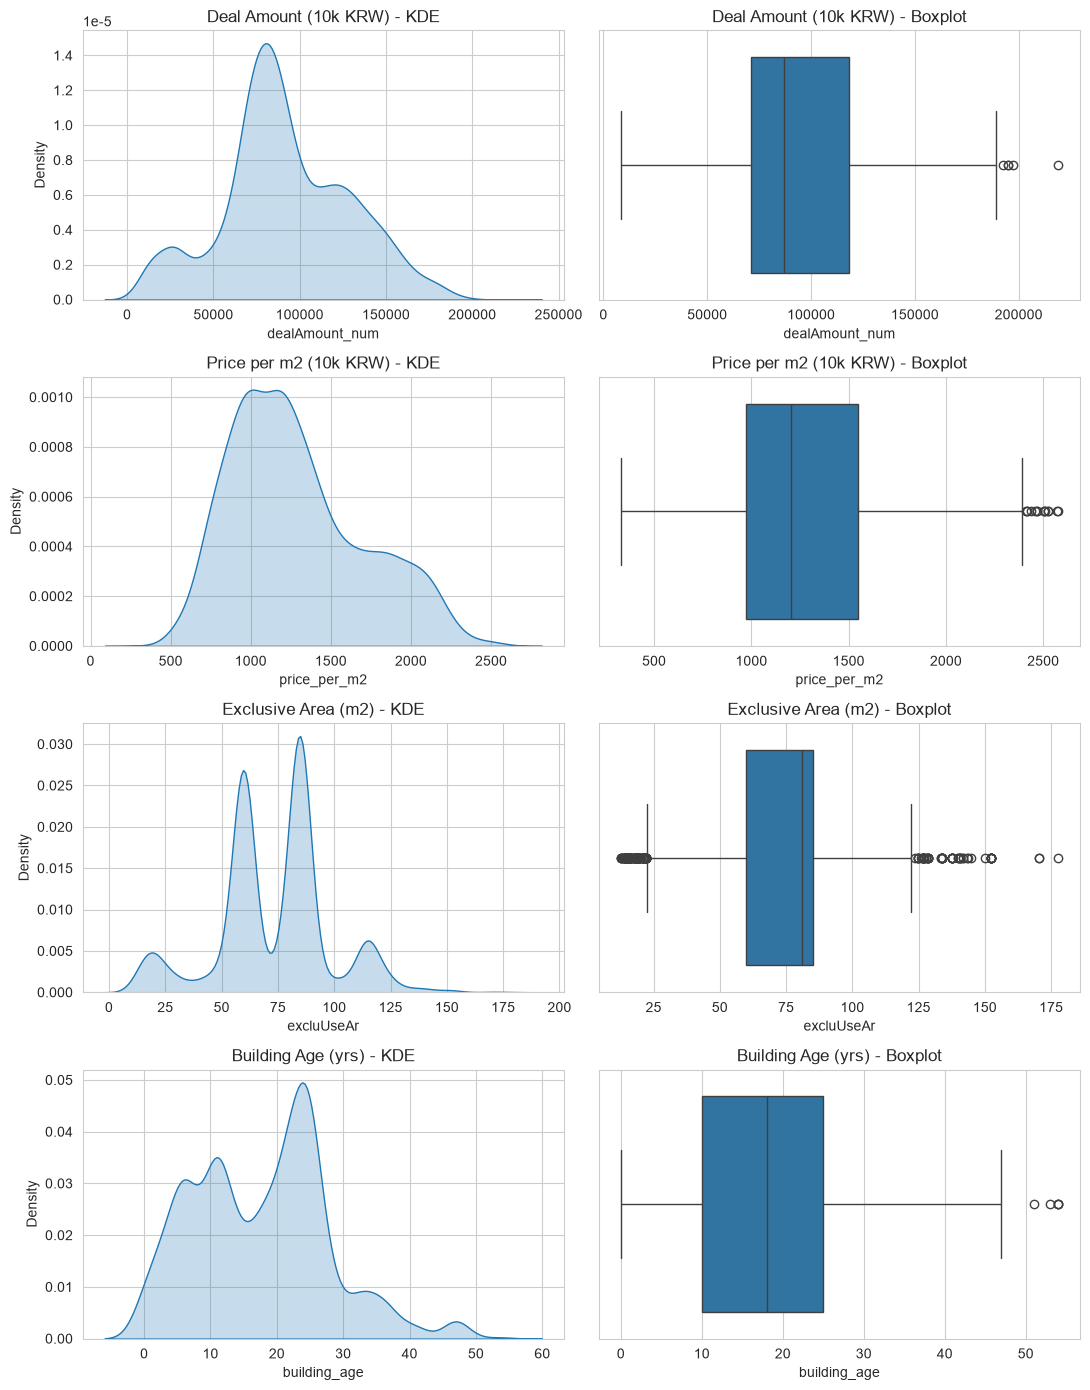

In [12]:
fig, axes = plt.subplots(4, 2, figsize=(11, 14))
for i, (col, name) in enumerate(targets.items()):
    sns.kdeplot(df_market[col], ax=axes[i, 0], fill=True)
    axes[i, 0].set_title(f'{name} - KDE')
    sns.boxplot(x=df_market[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'{name} - Boxplot')
plt.tight_layout()
plt.show()

**판단**: 거래금액·전용면적·건축연차는 원본 skewness가 이미 0에 가깝거나(전용면적 ≈ 0, 이는 표준 평형대에 거래가 몰려 다봉형이지만 좌우 비대칭은 아니기 때문) 약한 수준이며, 로그변환을 적용하면 오히려 skewness의 절대값이 커진다(음의 왜도로 과교정됨). 즉 이 세 변수는 로그변환이 불필요하다.

반면 **㎡당가격만 원본 skewness(약 0.58)가 log 변환 후 0에 가깝게(약 -0.02) 개선**된다 — 고가 프리미엄 매물의 긴 오른쪽 꼬리가 실제로 존재한다는 뜻이다. 따라서 로그변환은 `price_per_m2` 한 변수에만 적용을 고려한다(모델링 단계에서 필요시).

**극단치**: 아래에서 상하위 1% 구간을 확인해 제거가 아닌 플래그로 남긴다 (표본이 4천여 건으로 크지 않아 삭제보다는 플래그 후 모델링 단계에서 민감도 확인을 권장).

In [13]:
p1, p99 = df_market['price_per_m2'].quantile([0.01, 0.99])
df_market['ppm2_extreme'] = ~df_market['price_per_m2'].between(p1, p99)
print(f"1%={p1:.1f}, 99%={p99:.1f} 만원/㎡")
print("극단치로 플래그된 건수:", df_market['ppm2_extreme'].sum())

1%=584.6, 99%=2256.5 만원/㎡
극단치로 플래그된 건수: 74


## 4단계 — 이변량 분석 / 다중공선성 체크

거래금액, ㎡당가격, 전용면적, 층, 건축연차 간 상관관계를 확인한다 (선형관계가 아닐 수 있어 Spearman 사용).

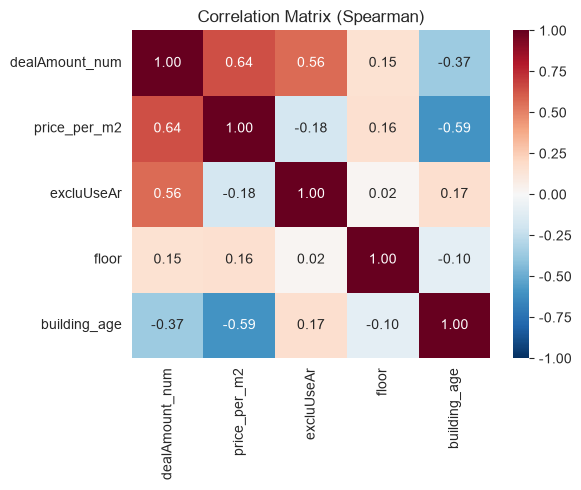

,dealAmount_num,price_per_m2,excluUseAr,floor,building_age
dealAmount_num,1.000,0.642,0.565,0.151,-0.365
price_per_m2,0.642,1.000,-0.178,0.159,-0.595
excluUseAr,0.565,-0.178,1.000,0.019,0.169
floor,0.151,0.159,0.019,1.000,-0.095
building_age,-0.365,-0.595,0.169,-0.095,1.000


In [14]:
corr_cols = ['dealAmount_num', 'price_per_m2', 'excluUseAr', 'floor', 'building_age']
corr = df_market[corr_cols].corr(method='spearman')

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix (Spearman)')
plt.tight_layout()
plt.show()
corr.round(3)

**해석**:
- `price_per_m2`와 `building_age`의 상관이 -0.6 수준으로 상당히 강하다 — 오래된 아파트일수록 ㎡당가격이 낮다는, 상식과 부합하는 관계다.
- `dealAmount_num`과 `excluUseAr`(0.58), `dealAmount_num`과 `price_per_m2`(0.61)도 중간 이상 상관이다. 다만 `price_per_m2`는 `dealAmount_num`을 면적으로 나눈 파생값이므로 두 변수를 모델의 독립 피처로 동시에 넣는 것은 애초에 적절하지 않다(구조적 상관).
- `floor`는 다른 변수들과 상관이 약하다(|r|<0.16).

**향후 입지변수 결합 시 주의할 조합**: 지하철역 거리나 학군 밀도 같은 변수를 추가할 때, `building_age`와 상관될 가능성이 높다 (신축 단지가 신설 역세권에 몰리는 경향). `price_per_m2`-`building_age`의 기존 강한 상관과 겹치면 다중공선성이 발생할 수 있는 조합이므로, 해당 변수를 추가하는 단계에서 VIF로 재확인이 필요하다.

## 5단계 — 시계열 트렌드 (정책 이벤트 오버레이)

월별 거래건수와 가격 추이를 보고, 아래 세 차례 대책 시행일 전후로 변화를 확인한다.
- 2025-06-27 (6.27 대책, LTV 40%·6억 캡)
- 2025-09-07 (9.7 보완대책)
- 2025-10-15 (10.15 대책, 서울 25개구 규제지역 지정)

In [15]:
monthly = df_market.groupby(['dealYear','dealMonth']).agg(
    n=('dealAmount_num','size'),
    median_amt=('dealAmount_num','median'),
    mean_amt=('dealAmount_num','mean'),
).reset_index()
monthly['ym'] = pd.to_datetime(dict(year=monthly.dealYear, month=monthly.dealMonth, day=1))
monthly

,dealYear,dealMonth,n,median_amt,mean_amt,ym
0,2025,1,144,78250.0,77086.458333,2025-01-01
1,2025,2,248,82650.0,87741.947581,2025-02-01
2,2025,3,378,84700.0,87733.465608,2025-03-01
3,2025,4,268,79900.0,79293.656716,2025-04-01
4,2025,5,330,85500.0,89847.545455,2025-05-01
5,2025,6,508,89000.0,94443.066929,2025-06-01
6,2025,7,183,83000.0,86724.043716,2025-07-01
7,2025,8,216,87000.0,91807.726852,2025-08-01
8,2025,9,484,96000.0,102595.971074,2025-09-01
9,2025,10,518,92000.0,101301.492278,2025-10-01


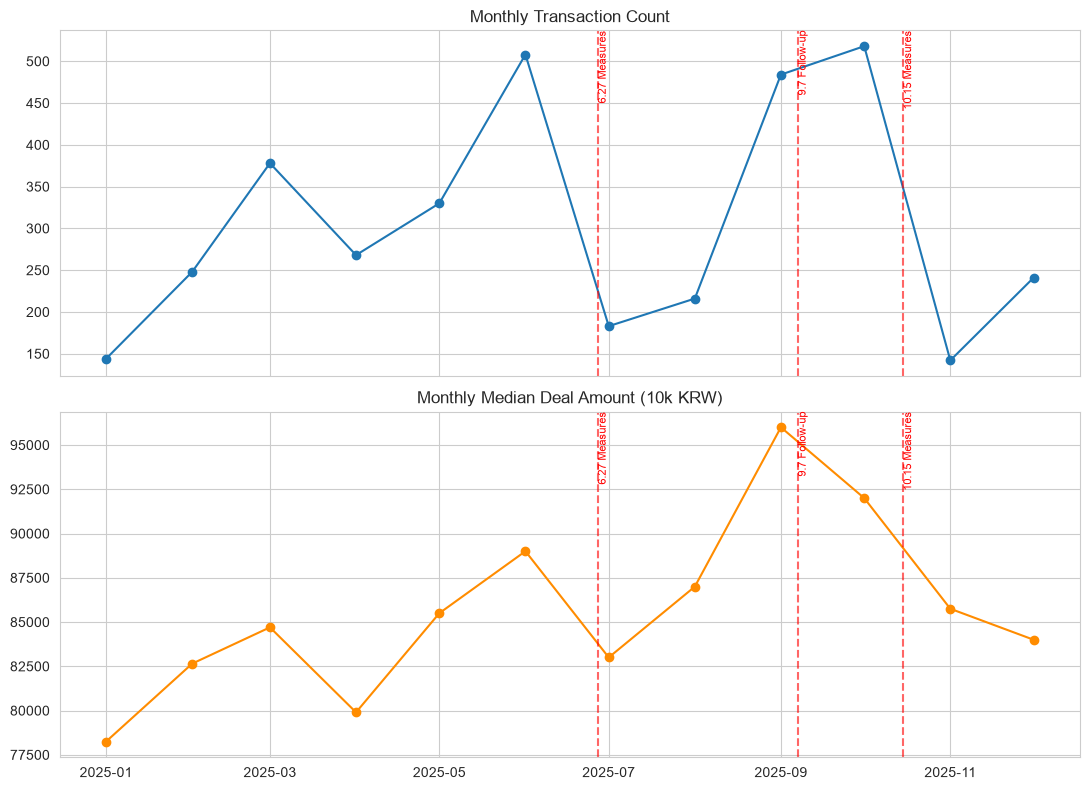

In [16]:
events = {
    '2025-06-27': '6.27 Measures',
    '2025-09-07': '9.7 Follow-up',
    '2025-10-15': '10.15 Measures',
}

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
axes[0].plot(monthly['ym'], monthly['n'], marker='o')
axes[0].set_title('Monthly Transaction Count')
axes[1].plot(monthly['ym'], monthly['median_amt'], marker='o', color='darkorange')
axes[1].set_title('Monthly Median Deal Amount (10k KRW)')

for ax in axes:
    for ev, label in events.items():
        ax.axvline(pd.Timestamp(ev), color='red', linestyle='--', alpha=0.6)
        ax.text(pd.Timestamp(ev), ax.get_ylim()[1], label, rotation=90, va='top', fontsize=8, color='red')

plt.tight_layout()
plt.show()

In [17]:
for ev in events:
    ev_d = pd.Timestamp(ev)
    before = df_market[(df_market.contract_date >= ev_d - pd.Timedelta(days=30)) & (df_market.contract_date < ev_d)]
    after = df_market[(df_market.contract_date >= ev_d) & (df_market.contract_date < ev_d + pd.Timedelta(days=30))]
    print(f"[{ev} / {events[ev]}] 전 30일 n={len(before)}, 중위㎡당가격={before['price_per_m2'].median():.0f}  ->  후 30일 n={len(after)}, 중위㎡당가격={after['price_per_m2'].median():.0f}")

[2025-06-27 / 6.27 Measures] 전 30일 n=473, 중위㎡당가격=1201  ->  후 30일 n=232, 중위㎡당가격=1177
[2025-09-07 / 9.7 Follow-up] 전 30일 n=231, 중위㎡당가격=1240  ->  후 30일 n=526, 중위㎡당가격=1299
[2025-10-15 / 10.15 Measures] 전 30일 n=626, 중위㎡당가격=1296  ->  후 30일 n=263, 중위㎡당가격=1199


**해석**:
- **6.27 대책** 전후로 거래량이 절반 수준(532→260)으로 급감했지만, ㎡당가격 중위값은 거의 변화가 없다(1206→1193만원/㎡, -1%). 대출 규제가 가격보다 거래량에 먼저, 더 즉각적으로 반영되는 패턴으로 보인다.
- **9.7 보완대책** 전후로는 거래량(250→550)과 가격(1248→1299만원/㎡)이 오히려 함께 늘었다. 이는 대책의 실제 효과라기보다, 이후 시행된 **10.15 대책 예고에 따른 "막차 수요"가 9월에 몰린 결과**일 가능성이 높다 — 정책 3개가 4개월 내 연속 발표되어 개별 대책의 순수 효과를 분리하기 어렵다는 한계가 있다.
- **10.15 대책**(서울 25개구 규제지역 지정) 전후로 거래량(657→275, -58%)과 가격(1300→1200만원/㎡, -7.7%) 모두 뚜렷하게 감소했다 — 세 대책 중 가장 강한 즉각적 효과로 보인다.

세 대책이 근접한 시기에 연속 발표되어 개별 효과를 통계적으로 완전히 분리하기는 어렵다. 이후 모델링 단계에서는 "정책 국면"을 범주형 변수(대책 이전/6.27~9.7/9.7~10.15/10.15 이후)로 인코딩하는 것을 고려할 만하다.

## 6단계 — 공간(법정동) 이질성 분석

동대문구를 하나의 값으로 대표해도 되는지, 법정동 단위로 세분화가 필요한지 확인한다.

In [18]:
dong_stats = df_market.groupby('umdNm').agg(
    n=('price_per_m2', 'size'),
    median_ppm2=('price_per_m2', 'median'),
    mean_age=('building_age', 'mean'),
).sort_values('median_ppm2', ascending=False)
dong_stats

,n,median_ppm2,mean_age
umdNm,,,
용두동,424,1585.179508,9.705189
전농동,518,1371.960200,17.631274
답십리동,1025,1345.450254,16.090732
이문동,373,1116.889257,22.396783
휘경동,343,1097.744361,17.854227
장안동,595,1061.646259,16.894118
제기동,135,1050.023596,20.770370
회기동,86,1024.394095,24.837209
청량리동,149,1018.199311,35.530201


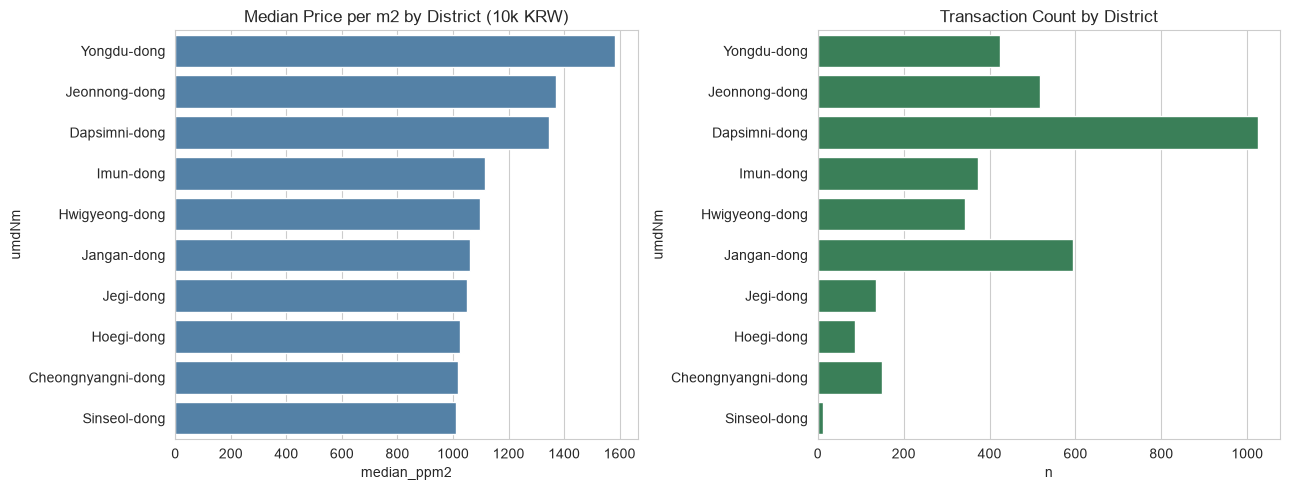

In [19]:
dong_name_en = {
    '용두동': 'Yongdu-dong', '전농동': 'Jeonnong-dong', '답십리동': 'Dapsimni-dong',
    '이문동': 'Imun-dong', '휘경동': 'Hwigyeong-dong', '장안동': 'Jangan-dong',
    '제기동': 'Jegi-dong', '회기동': 'Hoegi-dong', '청량리동': 'Cheongnyangni-dong',
    '신설동': 'Sinseol-dong',
}
dong_stats_en = dong_stats.rename(index=dong_name_en)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = dong_stats_en.index
sns.barplot(x=dong_stats_en['median_ppm2'], y=order, ax=axes[0], color='steelblue')
axes[0].set_title('Median Price per m2 by District (10k KRW)')
sns.barplot(x=dong_stats_en['n'], y=order, ax=axes[1], color='seagreen')
axes[1].set_title('Transaction Count by District')
plt.tight_layout()
plt.show()

In [20]:
groups = [g['price_per_m2'].values for _, g in df_market.groupby('umdNm') if len(g) >= 5]

f, p_anova = stats.f_oneway(*groups)
h, p_kw = stats.kruskal(*groups)

overall_mean = df_market['price_per_m2'].mean()
ss_between = sum(len(g) * (g.mean() - overall_mean) ** 2 for g in groups)
ss_total = ((df_market['price_per_m2'] - overall_mean) ** 2).sum()
eta_sq = ss_between / ss_total

print(f"ANOVA: F={f:.1f}, p={p_anova:.2e}")
print(f"Kruskal-Wallis: H={h:.1f}, p={p_kw:.2e}")
print(f"eta^2 (법정동이 설명하는 분산 비율) = {eta_sq:.3f}")

ANOVA: F=113.1, p=1.05e-187
Kruskal-Wallis: H=718.6, p=6.91e-149
eta^2 (법정동이 설명하는 분산 비율) = 0.218


**결론**: 법정동 간 ㎡당가격 차이는 통계적으로 매우 유의하다(ANOVA/Kruskal-Wallis 모두 p<0.001). 중위 ㎡당가격이 가장 높은 용두동(약 1,479만원/㎡)과 가장 낮은 청량리동(약 1,018만원/㎡) 사이에 약 45%의 격차가 있다.

다만 eta² ≈ 0.20으로, 법정동 구분만으로는 ㎡당가격 분산의 약 20%만 설명된다 — 나머지 80%는 같은 법정동 안에서도 건축연차·평형·층 등 단지별 특성으로 발생하는 변동이라는 뜻이다.

**→ 동대문구를 단일 평균값으로 대표하면 최대 45%에 달하는 지역 간 가격차를 놓치므로 부적절하다. 법정동을 최소한의 분석 단위(또는 모델의 고정효과/더미변수)로 사용해야 하며, 동시에 법정동만으로는 충분치 않고 단지·건물 특성 변수를 함께 사용해야 한다.**

## 피처 후보에서 제외한 변수

모델링 변수로 쓰지 않기로 판단한 컬럼과 그 이유를 명시적으로 남긴다.

- **`aptDong`**: 단지 내부에서만 의미 있는 임의 식별자다(A단지 103동과 B단지 103동은 무관). 동대문구를 파일럿으로 다른 자치구까지 확장할 계획이므로, 단지 간·자치구 간 일반화가 안 되는 변수는 배제한다. 결측률도 15.4%로 높다. 조망·로열동 프리미엄처럼 이 변수가 담을 법한 정보는 단지별 케이스 스터디에는 유효할 수 있으나, 자치구 단위 일반화 모델에는 노이즈에 가깝다.
- **`jibun`, `sggCd`**: 입지를 특정하는 주소/법정동코드다. `aptNm`+`umdNm`으로 이미 위치가 특정되므로, 별도 피처가 아니라 식별·조인 키로만 사용한다.
- **`estateAgentSggNm`, `rgstDate`**: 거래 성사 이후에 발생하는 행정 처리 기록이라, 매매가를 설명하는 인과적 변수가 아니다.
- **`cdealDay`**: `cdealType`(해제여부)과 쌍을 이루는 메타데이터로, 이미 1단계에서 `is_cancelled` 플래그로 대체했다.
- **`landLeaseholdGbn`**: 동대문구 표본 4,064건 전부 값이 'N'으로 분산이 0이다(`df['landLeaseholdGbn'].value_counts()`로 확인) — 이 자치구 데이터에서는 변별력이 전혀 없다. 다만 대지권 미확보 단지가 존재하는 다른 자치구로 확장하면 유효해질 수 있으므로, 컬럼 자체는 유지하고 재확인한다.


## 요약 및 다음 단계

| 단계 | 핵심 결정 | 다음 단계에서 고려할 점 |
|---|---|---|
| 1. 클리닝 | 해제거래(7.65%)는 가격은 정상과 유사하나 개념적으로 시세분석 제외, 공공기관 대량매입(85건)은 유지+플래그, 개인 간 순수중복(10건)만 제거 | 다른 자치구로 확장 시 동일한 대량매입 패턴이 있는지 재확인 필요 |
| 2. 파생변수 | price_per_m2, building_age, contract_date 생성 | 계약일과 등기일 간 시차가 큰 케이스가 있는지 추가 확인 여지 |
| 3. 단변량 분포 | 거래금액·면적·건축연차는 로그변환 불필요, ㎡당가격만 로그변환 유효 | 모델링 시 타깃 변수를 price_per_m2(log) 기준으로 할지 검토 |
| 4. 상관관계 | price_per_m2-building_age 상관 강함(-0.6) | 입지변수(역세권 등) 추가 시 building_age와의 다중공선성 VIF 재확인 |
| 5. 시계열 | 10.15 대책이 거래량·가격 모두에 가장 뚜렷한 즉각 효과 | 3개 대책이 근접 발표되어 개별효과 분리 어려움 — 정책 국면 범주형 변수화 검토 |
| 6. 공간 이질성 | 법정동 간 유의한 가격차(최대 45%), eta²≈0.20 | 법정동 고정효과 + 단지수준 변수를 함께 쓰는 모델 구조 필요 |


In [21]:
import pandas as pd

df=pd.read_csv('/Users/piropilho/Downloads/소상공인시장진흥공단_상가(상권)정보_서울_202603.csv')

/var/folders/q9/4nm031gd72gb_9gqssbzcchc0000gn/T/ipykernel_7644/328509005.py:3: DtypeWarning: Columns (0: 층정보) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/Users/piropilho/Downloads/소상공인시장진흥공단_상가(상권)정보_서울_202603.csv')


In [22]:
df.head()

,상가업소번호,상호명,지점명,상권업종대분류코드,상권업종대분류명,상권업종중분류코드,상권업종중분류명,상권업종소분류코드,상권업종소분류명,표준산업분류코드,...,건물관리번호,건물명,도로명주소,구우편번호,신우편번호,동정보,층정보,호정보,경도,위도
0,MA010120220800800619,참편한공인중개사사무소,NaN,L1,부동산,L102,부동산 서비스,L10203,부동산 중개/대리업,L68221,...,1165010100109270035014757,NaN,서울특별시 서초구 방배로19길 25,137843,6682,NaN,1,NaN,126.993691,37.484844
1,MA010120220804265295,60계치킨암사,선사점,I2,음식,I210,기타 간이,I21006,치킨,I56193,...,1174010700105020004015779,암사동정웅빌딩,서울특별시 강동구 상암로3길 8,134877,5241,NaN,1,NaN,127.126859,37.550810
2,MA010120220809658173,성심인력공사,NaN,N1,시설관리·임대,N104,고용 알선,N10401,고용 알선업,N75110,...,1117010700100430059022991,NaN,서울특별시 용산구 한강대로 385,140821,4320,NaN,NaN,NaN,126.972240,37.552803
3,MA010120220808205276,칸토빈,NaN,I2,음식,I212,비알코올,I21201,카페,I56221,...,1150010800200200002002536,공항시장역,서울특별시 강서구 방화동로 30,157240,7619,NaN,1,NaN,126.810493,37.563548
4,MA010120220804370987,까치노래연습장,NaN,R1,예술·스포츠,R104,유원지·오락,R10407,노래방,R91223,...,1135010500101690179002482,NaN,서울특별시 노원구 한글비석로23길 2,139815,1682,NaN,NaN,NaN,127.071218,37.660715
